<a href="https://colab.research.google.com/github/Moe-phantom/Beyondinfinity/blob/main/6_S189_Activity_1_Exploring_Word_Embeddings_No_Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embeddings: Word2Vec → Gensim → Analysis → spaCy Applications

## Why Word Embeddings?

> *"You shall know a word by the company it keeps."* — J.R. Firth (1957)

Word embeddings are foundational to modern NLP. They transform discrete words into continuous vector spaces where semantic relationships become geometric relationships:

| Reason | Explanation |
|--------|-------------|
| **Semantic Meaning** | Similar words map to nearby points in the embedding space |
| **Compositionality** | Vector arithmetic captures analogies (king - man + woman ≈ queen) |
| **Efficiency** | Dense representations are more efficient than one-hot encodings |
| **Transfer Learning** | Pretrained embeddings boost downstream NLP tasks |

---

## What This Notebook Covers

This notebook provides a comprehensive exploration of word embeddings:

1. **Part 1 (PyTorch from scratch):** Implement Word2Vec **Skip-gram with Negative Sampling (SGNS)** and train on WikiText2.
2. **Part 2 (Gensim):** Train Word2Vec with `gensim` (CBOW vs Skip-gram), compare knobs, serialize models.
3. **Part 3 (Analysis):** Use pretrained vectors (e.g., GloVe) to study similarity, analogies, geometry, bias, visualization.
4. **Part 4 (spaCy):** Apply embeddings to similarity, sentence embeddings, sentiment baseline, and show static-embedding polysemy/context failures.

---

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain the **Word2Vec** training objectives (CBOW vs Skip-gram) and why **negative sampling** is used.
- Implement and train **SGNS** in PyTorch, including:
  - tokenization + vocabulary building
  - paragraph-safe context generation
  - subsampling frequent words
  - unigram$^{0.75}$ negative sampling
- Train Word2Vec in **gensim** and understand the effect of key hyperparameters.
- Analyze embedding spaces with **cosine similarity**, **analogy arithmetic**, simple **bias probes**, and **2D projections**.
- Use **spaCy** vectors for downstream tasks (sentence similarity, sentiment baseline) and articulate why static embeddings fail under **polysemy**.

---

This is an implementation-heavy workbook. Use your coding agent of preference but ensure you understand the intuition behind the different methods.

---

## 1. Setup

Run the next cells to install dependencies and configure the environment.

Notes:
- This notebook is designed for **Google Colab** but should also run locally with minor adjustments.
- We set seeds and select a device (CPU/GPU) to make experiments more repeatable.

### 1.1 Install dependencies

In [ ]:
!pip -q install portalocker gensim scikit-learn tqdm spacy datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.1 MB/s eta 0:00:00


### 1.2 Imports and Configuration

In [ ]:
import os, random, math, re
import numpy as np
import torch
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| cuda available:", torch.cuda.is_available())


device: cuda | cuda available: True


In [ ]:
import torch; print(torch.__version__)


2.9.0+cu126


---

## 2. Understanding Word2Vec (Training SGNS from Scratch in PyTorch)

### 2.1 Word2Vec in one page (the math you actually use)

Word2Vec has two classic training objectives:

- **CBOW:** predict the center word from surrounding context  
- **Skip-gram:** predict surrounding context words from a center word  

In practice, scalable implementations use **Skip-gram with Negative Sampling (SGNS)**.

For a positive pair $(c, o)$ (center $c$, context $o$):

$$
\mathcal{L}(c,o)= -\log\sigma(\mathbf{u}_c^\top \mathbf{v}_o)
- \sum_{k=1}^K \log\sigma\!\left(-\mathbf{u}_c^\top \mathbf{v}_{n_k}\right)
$$

- $\mathbf{u}_c$: "input" embedding of center word  
- $\mathbf{v}_o$: "output" embedding of context word  
- $n_k$ are negative samples from a noise distribution (often unigram$^{0.75}$)  
- $\sigma$ is the sigmoid  

This avoids an expensive full softmax over a large vocabulary.

### 2.2 Data: WikiText2 → paragraphs → tokens → vocab

We **preserve paragraph boundaries** to avoid creating center/context pairs that cross unrelated text.

In [ ]:
import re
from datasets import load_dataset

def basic_english(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    return text.split()

def wikitext2_paragraphs(split="train"):
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split=split)
    paragraphs = []
    for line in ds["text"]:
        line = re.sub(r"^\s+", "", line).replace("@", "")
        if re.match(r"^=", line):  # skip title-ish lines
            continue
        toks = basic_english(line)
        if toks:
            paragraphs.append(toks)
    return paragraphs


paragraphs = wikitext2_paragraphs("train")
print("num paragraphs:", len(paragraphs))
print("sample paragraph:", paragraphs[5000][:40])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

num paragraphs: 17553
sample paragraph: ['for', 'the', 'remainder', 'of', 'the', 'day', 'b', 'company', 'was', 'subjected', 'to', 'intense', 'indirect', 'fire', 'on', 'the', 'hinge', 'as', 'was', 'c', 'company', 'on', 'hill', '317', 'the', 'anti', 'tank', 'platoon', 'and', 'assault', 'pioneer', 'platoon', 'reinforced', 'c', 'company', 'with', 'a', 'platoon', 'of', 'c']


### 2.3 Build vocabulary with `<unk>` and a minimum frequency threshold

Words below `min_freq` become `<unk>`. This keeps the vocabulary manageable and reduces noise from ultra-rare tokens.

In [ ]:
class SimpleVocab:
    def __init__(self, token_to_idx, idx_to_token, default_token="<unk>"):
        self.token_to_idx = token_to_idx
        self.idx_to_token = idx_to_token
        self.default_index = self.token_to_idx.get(default_token, 0)

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token: str) -> int:
        return self.token_to_idx.get(token, self.default_index)

    def lookup_token(self, idx: int) -> str:
        if 0 <= idx < len(self.idx_to_token):
            return self.idx_to_token[idx]
        return self.idx_to_token[self.default_index]

def build_vocab(paragraphs, min_freq=20, specials=("<unk>",)):
    # count tokens
    cnt = Counter()
    for p in paragraphs:
        cnt.update(p)

    # start with specials
    idx_to_token = list(specials)
    token_to_idx = {t:i for i,t in enumerate(idx_to_token)}

    # add tokens meeting min_freq (sorted for determinism)
    tokens = [t for t, c in cnt.items() if c >= min_freq and t not in token_to_idx]
    tokens.sort()
    for t in tokens:
        token_to_idx[t] = len(idx_to_token)
        idx_to_token.append(t)

    return SimpleVocab(token_to_idx, idx_to_token, default_token=specials[0])

vocab = build_vocab(paragraphs, min_freq=30)
V = len(vocab)
print("vocab size:", V)


vocab size: 6060


### 2.4 Encode paragraphs to integer token IDs

In [ ]:
def encode_paragraphs(paragraphs, vocab):
    return [[vocab[t] for t in p] for p in paragraphs]

encoded_paragraphs = encode_paragraphs(paragraphs, vocab)
print(encoded_paragraphs[5000][:30], "=>", [vocab.lookup_token(i) for i in encoded_paragraphs[5000][:30]])


[2394, 5455, 4564, 3849, 5455, 1656, 751, 1379, 5870, 0, 5523, 2964, 0, 2343, 3880, 5455, 0, 657, 5870, 1033, 1379, 3880, 2740, 0, 5455, 561, 5385, 4147, 530, 670] => ['for', 'the', 'remainder', 'of', 'the', 'day', 'b', 'company', 'was', '<unk>', 'to', 'intense', '<unk>', 'fire', 'on', 'the', '<unk>', 'as', 'was', 'c', 'company', 'on', 'hill', '<unk>', 'the', 'anti', 'tank', 'platoon', 'and', 'assault']


### 2.5 Subsampling frequent words (as in the original Word2Vec)

Frequent words ("the", "of", "and") dominate training unless we downsample them.

Word2Vec uses:

$$
P(\text{discard } w)
= 1 - \sqrt{\frac{t}{f(w)}}
$$

where $t$ is typically $10^{-5}$ and $f(w)$ is the empirical unigram probability.

In [ ]:
def word_frequencies(encoded_paragraphs, V):
    cnt = Counter()
    for p in encoded_paragraphs:
        cnt.update(p)
    freqs = np.zeros(V, dtype=np.int64)
    for i, c in cnt.items():
        freqs[i] = c
    total = freqs.sum()
    probs = freqs / total
    return freqs, probs

freqs, probs = word_frequencies(encoded_paragraphs, V)

def subsample_paragraph(p, probs, t=1e-5):
    # discard probability
    f = probs[p]
    p_discard = np.maximum(0.0, 1.0 - np.sqrt(t / (f + 1e-12)))
    keep = np.random.rand(len(p)) > p_discard
    return [w for w,k in zip(p, keep) if k]

subsampled = [subsample_paragraph(p, probs, t=1e-5) for p in encoded_paragraphs]
subsampled = [p for p in subsampled if len(p) >= 5]
print("paragraphs after subsampling:", len(subsampled))


paragraphs after subsampling: 14385


### 2.6 Create training pairs: Skip-gram (center → each context token)

We use a **dynamic window size** (as in the original), sampling window radius uniformly from $[1, W]$.

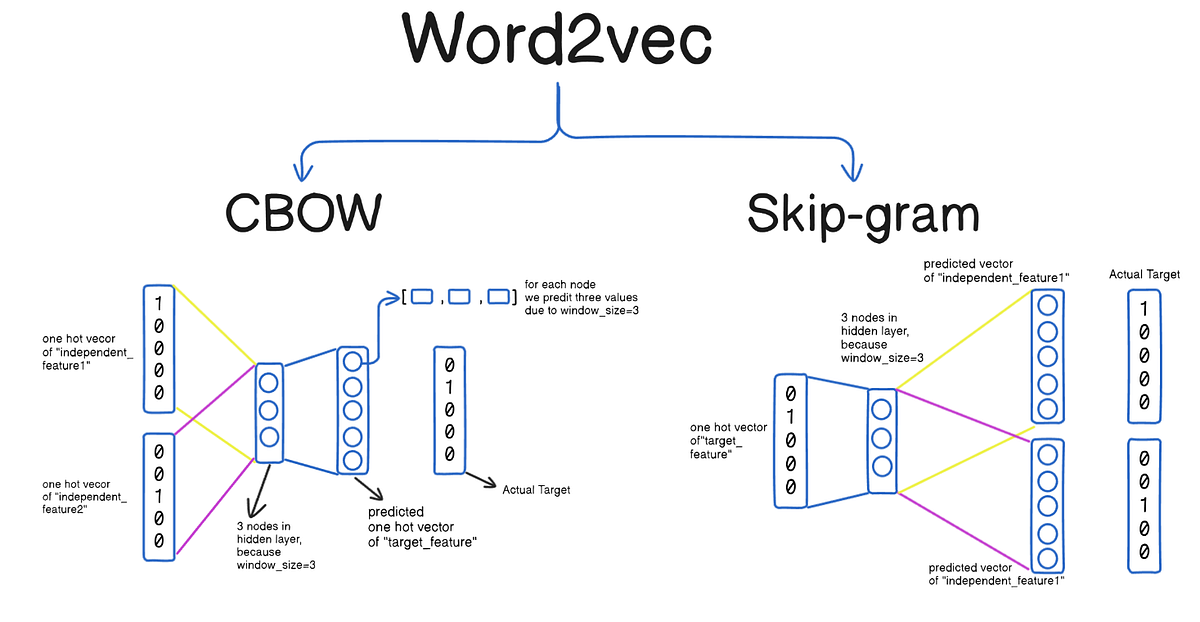

In [ ]:
def generate_skipgram_pairs(paragraphs, max_window=5):
    for p in paragraphs:
        n = len(p)
        for i, center in enumerate(p):
            window = random.randint(1, max_window)
            left = max(0, i - window)
            right = min(n, i + window + 1)
            for j in range(left, right):
                if j == i:
                    continue
                yield center, p[j]  # (center, context)

# quick sanity check
tmp = [["this","is","a","tiny","test","paragraph"]]
tmp_enc = encode_paragraphs(tmp, vocab)
pairs = list(generate_skipgram_pairs(tmp_enc, max_window=2))[:10]
pairs_decoded = [(vocab.lookup_token(c), vocab.lookup_token(o)) for c,o in pairs]
pairs_decoded


[('this', 'is'),
 ('is', 'this'),
 ('is', 'a'),
 ('a', 'this'),
 ('a', 'is'),
 ('a', '<unk>'),
 ('a', 'test'),
 ('<unk>', 'a'),
 ('<unk>', 'test'),
 ('test', '<unk>')]

### 2.7 Negative sampling distribution (unigram$^{0.75}$)

Noise distribution:

$$
P_n(w) \propto f(w)^{0.75}
$$

We precompute a categorical distribution used by `torch.multinomial`.

In [ ]:
def negative_sampling_distribution(freqs, power=0.75):
    f = freqs.astype(np.float64)
    f = np.power(f, power)
    f = f / (f.sum() + 1e-12)
    return torch.tensor(f, dtype=torch.float)

neg_dist = negative_sampling_distribution(freqs, power=0.75).to(device)
print("neg_dist sum:", float(neg_dist.sum()))


neg_dist sum: 1.0


### 2.8 PyTorch Dataset (Iterable) + Collate

We wrap skip-gram pair generation in a PyTorch `IterableDataset` for cleaner batching.

In [ ]:
from torch.utils.data import IterableDataset, DataLoader

class SkipGramIterableDataset(IterableDataset):
    def __init__(self, paragraphs, max_window=5):
        super().__init__()
        self.paragraphs = paragraphs
        self.max_window = max_window

    def __iter__(self):
        return generate_skipgram_pairs(self.paragraphs, self.max_window)

def collate_sg(batch):
    # batch: list of (center, context)
    centers = torch.tensor([c for c,o in batch], dtype=torch.long)
    contexts = torch.tensor([o for c,o in batch], dtype=torch.long)
    return centers, contexts

BATCH_SIZE = 2048
train_ds = SkipGramIterableDataset(subsampled, max_window=5)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, collate_fn=collate_sg, num_workers=0)


### 2.9 Model: Skip-gram with Negative Sampling (SGNS)

Two embedding matrices:
- `in_embed`: for centers
- `out_embed`: for contexts/negatives

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SGNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.in_embed  = nn.Embedding(vocab_size, dim)
        self.out_embed = nn.Embedding(vocab_size, dim)

        # Initialization similar to common practice
        init_range = 0.5 / dim
        self.in_embed.weight.data.uniform_(-init_range, init_range)
        self.out_embed.weight.data.zero_()

    def forward(self, centers, pos_contexts, neg_contexts):
        """
        centers:      (B,)
        pos_contexts: (B,)
        neg_contexts: (B, K)
        """
        u = self.in_embed(centers)                  # (B, D)
        v_pos = self.out_embed(pos_contexts)        # (B, D)
        v_neg = self.out_embed(neg_contexts)        # (B, K, D)

        # Positive score: u·v_pos
        pos_score = torch.sum(u * v_pos, dim=1)     # (B,)
        pos_loss = F.logsigmoid(pos_score)          # log σ(u·v_pos)

        # Negative score: u·v_neg
        neg_score = torch.bmm(v_neg, u.unsqueeze(2)).squeeze(2)  # (B, K)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)           # Σ log σ(-u·v_neg)

        # Maximize pos_loss + neg_loss -> minimize negative
        return -(pos_loss + neg_loss).mean()

    @torch.no_grad()
    def get_input_embeddings(self):
        return self.in_embed.weight.detach()

    @torch.no_grad()
    def get_output_embeddings(self):
        return self.out_embed.weight.detach()


### 2.10 Training loop (robust + evaluation hooks)

We sample negatives per batch using `torch.multinomial`.

In [ ]:
from tqdm import tqdm

def sample_negatives(batch_size, K, neg_dist):
    # returns (B, K)
    return torch.multinomial(neg_dist, num_samples=batch_size * K, replacement=True).view(batch_size, K)

def train_sgns(model, loader, neg_dist, steps=2000, K=10, lr=1e-2, grad_clip=5.0, log_every=200):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    it = iter(loader)

    for step in tqdm(range(1, steps+1)):
        try:
            centers, contexts = next(it)
        except StopIteration:
            it = iter(loader)
            centers, contexts = next(it)

        centers = centers.to(device)
        contexts = contexts.to(device)
        negs = sample_negatives(centers.size(0), K, neg_dist).to(device)

        loss = model(centers, contexts, negs)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        losses.append(float(loss.item()))
        if step % log_every == 0:
            print(f"step {step:5d} | loss {np.mean(losses[-log_every:]):.4f}")

    return losses


#### Train SGNS

Adjust `steps`, `DIM`, and `BATCH_SIZE` based on compute budget. For classroom use, start with smaller steps, then scale up.

In [ ]:
DIM = 300
model = SGNS(V, DIM).to(device)

losses = train_sgns(
    model, train_loader, neg_dist,
    steps=5000, K=15, lr=2e-3, log_every=250
)


  5%|▌         | 265/5000 [00:02<00:49, 96.59it/s]

step   250 | loss 5.8543


 10%|█         | 524/5000 [00:05<00:33, 133.53it/s]

step   500 | loss 3.9784


 15%|█▌        | 758/5000 [00:08<01:21, 52.01it/s]

...

step  4500 | loss 3.6159


 95%|█████████▌| 4768/5000 [00:31<00:01, 171.90it/s]

step  4750 | loss 3.6076


100%|██████████| 5000/5000 [00:33<00:00, 151.12it/s]

step  5000 | loss 3.5826


#### Plot loss

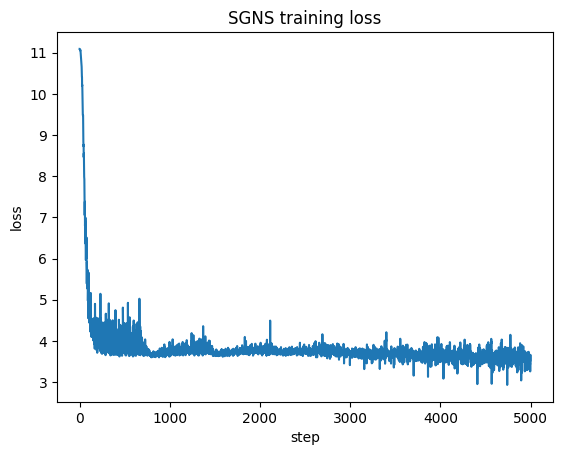

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.title("SGNS training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()


### 2.11 Inspect embeddings: cosine neighbors

Quick sanity check: do learned embeddings cluster semantically?

In [ ]:
@torch.no_grad()
def most_similar(word, emb, vocab, topk=10):
    emb = F.normalize(emb, dim=1)
    idx = vocab[word]
    q = emb[idx]
    sims = torch.mv(emb, q)
    vals, inds = torch.topk(sims, topk+1)  # includes itself
    out = []
    for v,i in zip(vals.tolist(), inds.tolist()):
        tok = vocab.lookup_token(i)
        if tok == word:
            continue
        out.append((tok, v))
        if len(out) >= topk:
            break
    return out

E = model.get_input_embeddings().to(device)

for w in ["king", "queen", "france", "paris", "music", "computer"]:
    print("\n", w, "=>", most_similar(w, E, vocab, topk=8))



 king => [('bishop', 0.8250868320465088), ('son', 0.815028190612793), ('henry', 0.8034193515777588), ('ruler', 0.7967809438705444), ('throne', 0.7928418517112732), ('lord', 0.7743485569953918), ('mary', 0.7685366868972778), ('grandfather', 0.7652186155319214)]

 queen => [('lord', 0.8131558895111084), ('frederick', 0.8086683750152588), ('throne', 0.8070083260536194), ('durham', 0.8037570714950562), ('sons', 0.7985330820083618), ('abbey', 0.795374870300293), ('knights', 0.7925165891647339), ('abbot', 0.781434178352356)]

 france => [('austria', 0.8222915530204773), ('1891', 0.7992573976516724), ('1909', 0.7954378128051758), ('treaty', 0.7820901870727539), ('1895', 0.7715656161308289), ('nations', 0.7668814063072205), ('1917', 0.7654504776000977), ('pitman', 0.7641032934188843)]

 paris => [('clinton', 0.8159315586090088), ('berlin', 0.8089563250541687), ('operas', 0.80607670545578), ('opera', 0.795883059501648), ('revived', 0.794822096824646), ('wno', 0.7887174487113953), ('aw', 0.7822

### 2.12 Exercises (Part 2)

**Exercise 1 — CBOW vs Skip-gram (conceptual)**
1. Explain why Skip-gram often performs better on **rare words**.
2. Explain why CBOW can train faster on very large corpora.

(You must research)

---

## 3. Using Word2Vec with Gensim (modern API, CBOW/SG, training knobs)

### 3.1 Why gensim?

Gensim provides:
- Fast training (optimized routines)
- Convenient similarity/analogy APIs
- Easy saving/loading
- Defaults aligned with Word2Vec practice

In [ ]:
import gensim
import gensim.downloader as api
from gensim.models import Word2Vec


### 3.2 Small toy corpus (sanity)

We now use Gensim. Instead of fully building Word2Vec from scratch one may use popular libraries to quickly make use of these models.

We train on a tiny corpus first to confirm the API. Results will be limited because the dataset is small.

In [ ]:
documents = [
    "Perfect is the enemy of good.",
    "I'm still learning.",
    "Life is a journey, not a destination.",
    "Learning is not attained by chance; it must be sought with ardor and attended to with diligence.",
    "Be curious, not judgmental.",
    "Be stubborn about your goals and flexible about your methods.",
    "Nothing will work unless you do.",
    "Anyone who stops learning is old, whether at twenty or eighty.",
]

def simple_preprocess(s):
    s = s.lower()
    s = re.sub(r"[^a-z\s]", "", s)
    return [w for w in s.split() if len(w) > 1]

toy = [simple_preprocess(d) for d in documents]
toy[:2]


[['perfect', 'is', 'the', 'enemy', 'of', 'good'], ['im', 'still', 'learning']]

In [ ]:
toy_model = Word2Vec(
    sentences=toy,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,            # 1=skip-gram, 0=cbow
    negative=10,
    epochs=200,
    workers=2
)
toy_model.wv.most_similar("learning")


[('whether', 0.9980635643005371),
 ('diligence', 0.9978532791137695),
 ('with', 0.9978315830230713),
 ('by', 0.997610867023468),
 ('it', 0.9975478649139404),
 ('must', 0.9974167943000793),
 ('attended', 0.9974009990692139),
 ('chance', 0.997280478477478),
 ('and', 0.9972101449966431),
 ('attained', 0.997198760509491)]

#### Checkpoint question
- Why do we need many epochs on tiny corpora, but not on large corpora?

### 3.3 Train on a real corpus: `text8`

`text8` is a Wikipedia subset used frequently for embedding demos.

In [ ]:
corpus = api.load("text8")  # iterable of tokenized sentences


[==================================================] 100.0% 31.6/31.6MB downloaded


In [ ]:
from itertools import islice
import time

# --- speed knobs ---
N_SENTENCES = 1000        # text8 sentences are ~1000 tokens each.
VEC_SIZE    = 100        # 50–100 is fast
EPOCHS      = 5          # 1–3 is fast

workers = min(8, os.cpu_count() or 2)

# Materialize a small, repeatable subset (important for multiple epochs)
sentences = list(islice(corpus, N_SENTENCES))

print(f"Loaded {len(sentences):,} sentences. workers={workers}")
print("Example tokens:", sentences[0][:15])

t0 = time.perf_counter()
w2v = Word2Vec(
    sentences=sentences,
    vector_size=VEC_SIZE,
    window=5,
    min_count=2,          # keep vocab smaller + faster
    max_final_vocab=20000,# hard cap vocab size (big speed win)
    sg=1,                 # 1=skip-gram
    negative=5,           # fewer negatives = faster
    sample=1e-4,          # subsampling
    epochs=EPOCHS,
    workers=workers
)
dt = time.perf_counter() - t0
print(f"Trained Skip-gram (SGNS) in {dt:.1f}s")

probe = "queen" if "queen" in w2v.wv else w2v.wv.index_to_key[0]
print("Probe word:", probe)
w2v.wv.most_similar(probe, topn=10)


Loaded 1,000 sentences. workers=2
Example tokens: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including']
Trained Skip-gram (SGNS) in 149.8s
Probe word: queen


[('elizabeth', 0.7747277021408081),
 ('victoria', 0.723153293132782),
 ('king', 0.7180575132369995),
 ('consort', 0.6958256959915161),
 ('isabella', 0.6895803213119507),
 ('princess', 0.6767413020133972),
 ('prince', 0.6702451109886169),
 ('buckingham', 0.6518768072128296),
 ('anne', 0.6429175138473511),
 ('monarch', 0.6396710872650146)]

#### Compare CBOW vs Skip-gram quickly

In [ ]:
t0 = time.perf_counter()
w2v_cbow = Word2Vec(
    sentences=sentences,   # reuse the subset already loaded
    vector_size=VEC_SIZE,
    window=5,
    min_count=2,
    max_final_vocab=20000,
    sg=0,                  # 0=cbow
    negative=5,
    sample=1e-4,
    epochs=EPOCHS,
    workers=workers
)
print(f"Trained CBOW in {time.perf_counter()-t0:.1f}s")

probe = "queen" if ("queen" in w2v.wv and "queen" in w2v_cbow.wv) else w2v.wv.index_to_key[0]
print("Probe word:", probe)
print("SG  :", w2v.wv.most_similar(probe, topn=5))
print("CBOW:", w2v_cbow.wv.most_similar(probe, topn=5))

Trained CBOW in 43.6s
Probe word: queen
SG  : [('elizabeth', 0.7747277021408081), ('victoria', 0.723153293132782), ('king', 0.7180575132369995), ('consort', 0.6958256959915161), ('isabella', 0.6895803213119507)]
CBOW: [('elizabeth', 0.8309160470962524), ('king', 0.7584388256072998), ('prince', 0.748680830001831), ('princess', 0.7422716021537781), ('lady', 0.7070547342300415)]


### 3.4 Save / Load properly

- `.save()` stores full model state
- `.wv.save()` stores vectors-only (smaller, sufficient for similarity/analogy tasks)

In [ ]:
w2v.save("w2v_text8.model")
w2v2 = Word2Vec.load("w2v_text8.model")

w2v2.wv.save("w2v_text8.kv")
kv = gensim.models.KeyedVectors.load("w2v_text8.kv")

kv.most_similar("paris")[:5]


[('rodin', 0.7096740007400513),
 ('duc', 0.6948651671409607),
 ('le', 0.6870518922805786),
 ('sainte', 0.6758259534835815),
 ('lyon', 0.6756389141082764)]

### 3.5 Exercises (Part 3)

1. Increase `vector_size` from 50 → 200 → 400. How do neighbors change?
2. Reduce `min_count` from 10 → 2. What happens to noise / rare-word quality?
3. Compare `negative=5` vs `negative=20`. What changes in training time and quality?
4. Train **two models** with different random seeds. Are nearest neighbors stable?

---

## 4. Analysing Word Embeddings (Similarity, Analogies, Geometry, Bias, Visualization)

We use pretrained embeddings (e.g., **GloVe**) so results are meaningful and comparable across machines.

### GloVe: Global Vectors for Word Representation

GloVe is an unsupervised learning algorithm for obtaining vector representations (embeddings) for words. Developed by researchers at Stanford, it combines the benefits of two major model families: global matrix factorization (like LSA) and local context window methods (like Word2Vec).The fundamental intuition is that the "meaning" of a word can be derived from how often it appears with other words across a massive text corpus.

#### 1. The Core Intuition: Co-occurrence Probabilities

Unlike Word2Vec, which learns by stepping through a corpus one window at a time, GloVe starts by calculating a huge Global Co-occurrence Matrix.Let $X$ be the matrix of word-word co-occurrence counts, where $X_{ij}$ denotes the number of times word $j$ appears in the context of word $i$.

The Insight of RatiosThe authors argue that raw probabilities are less informative than the ratio of probabilities. Consider the concept of thermodynamics with words like "ice" and "steam": $P(solid | ice)$ should be high. $P(solid | steam)$ should be low.Therefore, the ratio $\frac{P(solid | ice)}{P(solid | steam)}$ should be very large.
Conversely, for a word like "water" (related to both) or "fashion" (related to neither), the ratio should be close to 1.

This ratio captures the relationship between words better than raw frequency.

#### 2. The Mathematical Objective

GloVe aims to learn word vectors $w_i$ and $w_j$ such that their dot product equals the logarithm of their probability of co-occurrence.This results in a Weighted Least Squares regression model.

The cost function $J$ is defined as:$$J = \sum_{i,j=1}^{V} f(X_{ij}) (w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$

Breakdown of the Equation:$w_i^T \tilde{w}_j$: The dot product of the two word vectors (similarity).$\log X_{ij}$: The natural log of the number of times they appear together. We want the dot product to predict this count. $b_i, \tilde{b}_j$: Bias terms to handle the fact that some words (like "the") appear frequently just because they are common, not because of specific context.$f(X_{ij})$: A weighting function. This is critical. It ensures that: Common word pairs (high $X_{ij}$) don't dominate the loss. Rare word pairs don't introduce too much noise.Usually defined as $f(x) = (x/x_{max})^\alpha$ (capped at 1.0).

#### 3. Why use GloVe?

Training Speed: Faster to train than Word2Vec on smaller corpora because it leverages global statistics immediately rather than iterating over windows. Semantic Arithmetic: Like Word2Vec, it preserves linear substructures:$$Vector(King) - Vector(Man) + Vector(Woman) \approx Vector(Queen)$$Global Context: It captures global corpus statistics directly, whereas Word2Vec only sees local context windows.

In [ ]:
import gensim.downloader as api
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

glove = api.load("glove-wiki-gigaword-50")  # 400k x 50
glove.vectors.shape


[==================================================] 100.0% 66.0/66.0MB downloaded


(400000, 50)

### 4.1 Nearest neighbors & cosine similarity

Cosine similarity is typically preferred in embedding spaces because magnitudes are not always meaningful; direction often encodes semantics.

In [ ]:
def cos(u, v):
    u = u.reshape(1, -1)
    v = v.reshape(1, -1)
    return float(cosine_similarity(u, v))

print("cos(king, queen):", cos(glove["king"], glove["queen"]))
print("cos(king, car):  ", cos(glove["king"], glove["car"]))
glove.most_similar("king")[:8]


cos(king, queen): 0.7839043140411377
cos(king, car):   0.2625660300254822


/tmp/ipython-input-2792988896.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(u, v))
/tmp/ipython-input-2792988896.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(u, v))


[('prince', 0.8236179351806641),
 ('queen', 0.7839043140411377),
 ('ii', 0.7746230363845825),
 ('emperor', 0.7736247777938843),
 ('son', 0.766719400882721),
 ('uncle', 0.7627150416374207),
 ('kingdom', 0.7542160749435425),
 ('throne', 0.7539913654327393)]

### 4.2 Analogies: 3CosAdd vs the "multiplicative" method

Classic analogy: "king – man + woman ≈ queen"

We'll implement and compare:
- **3CosAdd:** $\arg\max_w \cos(w, b - a + c)$
- **3CosMul:** $\arg\max_w \frac{\cos(w,b)\cos(w,c)}{\cos(w,a)+\epsilon}$

(Levy & Goldberg showed 3CosMul is often more stable.)

In [ ]:
glove.most_similar(positive=["king", "woman"], negative=["man"], topn=5)


[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904)]

#### Verify the "closer to king than queen" observation

In [ ]:
result = glove["king"] - glove["man"] + glove["woman"]
print("cos(result, king): ", cos(result, glove["king"]))
print("cos(result, queen):", cos(result, glove["queen"]))


cos(result, king):  0.8859834671020508
cos(result, queen): 0.8609580397605896


/tmp/ipython-input-2792988896.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(u, v))
/tmp/ipython-input-2792988896.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(u, v))


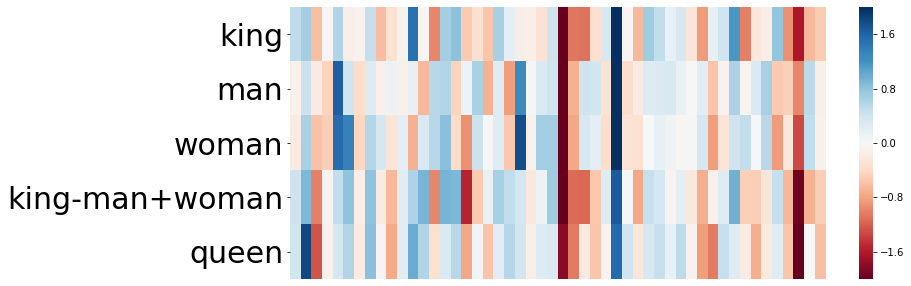

### 4.3 More analogies (including political/historical examples)

Note: availability depends on whether the token exists in the pretrained vocabulary.

In [ ]:
tests = [
    (["paris", "italy"], ["france"], "rome?"),
    (["tokyo", "france"], ["japan"], "paris?"),
    (["germany", "mussolini"], ["italy"], "hitler?"),
    (["hitler", "italy"], ["germany"], "mussolini?"),
]

for pos, neg, label in tests:
    print("\n", label, "pos=",pos,"neg=",neg)
    try:
        print(glove.most_similar(positive=pos, negative=neg, topn=5))
    except KeyError as e:
        print("missing word:", e)



 rome? pos= ['paris', 'italy'] neg= ['france']
[('rome', 0.8465589284896851), ('milan', 0.7766007781028748), ('turin', 0.7666355967521667), ('venice', 0.7591592073440552), ('madrid', 0.7565805315971375)]

 paris? pos= ['tokyo', 'france'] neg= ['japan']
[('paris', 0.9210439920425415), ('brussels', 0.7945173978805542), ('strasbourg', 0.7899346351623535), ('prohertrib', 0.7801742553710938), ('french', 0.7421016693115234)]

 hitler? pos= ['germany', 'mussolini'] neg= ['italy']
[('hitler', 0.8666031956672668), ('adolf', 0.8488795757293701), ('stalin', 0.7796745300292969), ('nazis', 0.7619557976722717), ('nazism', 0.7341997623443604)]

 mussolini? pos= ['hitler', 'italy'] neg= ['germany']
[('mussolini', 0.8580142855644226), ('fascist', 0.7116994261741638), ('napoleon', 0.6744531393051147), ('rome', 0.656495988368988), ('adolf', 0.6526973247528076)]


#### Exercise — Build your own analogy tests

1. Come up with 5 analogy tests.
2. Run them and interpret the results.

In [ ]:
analogies = [
    # ("king", "man", "woman", "queen"),  # a:b :: c:?
]

def predict_analogy(a, b, c, model, topn=5):
    # return topn candidates for a - b + c
    # model should be a gensim KeyedVectors-like object
    raise NotImplementedError


### 4.4 Embedding directions & bias (discussion)

**Gender direction:** $\vec{d} = \vec{he} - \vec{she}$

Projections onto this direction reveal stereotypical associations encoded in the corpus (and potentially amplified by the model).

#### Word projections on gendered axis

Positive = more "male"; negative = more "female" (by this simple axis).

| Word | Projection |
|------|------------|
| doctor | +0.11 |
| nurse | -0.20 |
| programmer | +0.15 |
| homemaker | -0.23 |

**Key questions:**
1. Where do these biases come from? (Corpus? Model? Training?)
2. How might they affect downstream applications?

In [ ]:
def projection_score(word, direction, kv):
    w = kv[word]
    d = direction
    return float(np.dot(w, d) / (np.linalg.norm(d) + 1e-12))

g = glove["he"] - glove["she"]

for w in ["nurse", "doctor", "engineer", "teacher", "homemaker", "scientist"]:
    if w in glove:
        print(w, projection_score(w, g, glove))


nurse -1.8800500631332397
doctor -0.6077626347541809
engineer 0.6240602135658264
teacher -0.5301152467727661
homemaker -1.5072760581970215
scientist 0.20178750157356262


#### Exercise **Optional** — Bias probes

1. Define your own "axis" (e.g., age, religion, nationality).
2. Project relevant words.
3. Discuss: what is "encoded" vs what is "caused by the model"?

---

## 5. Applying Word Embeddings with spaCy (Similarity → Sentence Embeddings → Sentiment → Polysemy)

In this part, we use spaCy's pretrained vectors for:
- Word similarity
- Analogies (manual)
- Sentence embeddings (pooling)
- Sentiment baseline classifier
- A clean polysemy/context failure demonstration

### 5.1 Load spaCy model

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy


In [ ]:
nlp = spacy.load("en_core_web_lg")
print("spaCy vectors dim:", nlp.vocab.vectors_length)


spaCy vectors dim: 300


### 5.2 Word vectors & similarity

In [ ]:
cat = nlp.vocab["cat"]
dog = nlp.vocab["dog"]
car = nlp.vocab["car"]

print("dim:", len(cat.vector))
print("sim(cat,dog):", cat.similarity(dog))
print("sim(cat,car):", cat.similarity(car))


dim: 300
sim(cat,dog): 0.8016854524612427
sim(cat,car): 0.3190753161907196


#### Exercise — cosine similarity properties
Verify:
1. symmetry: sim(a,b)=sim(b,a)
2. self-similarity: sim(a,a)=1 (approximately)
3. triangle inequality does **not** hold for cosine similarity

### 5.3 Most similar words in spaCy vocab (efficient version)

Looping over all spaCy vocab entries is instructive but slow. A faster approach:
- Build a matrix of normalized vectors once
- Use matrix-vector multiplication for cosine similarity

In [ ]:
import numpy as np
import spacy

nlp = spacy.load("en_core_web_lg")
vectors = nlp.vocab.vectors

# Build a correct row -> key mapping
row2key = {row: key for key, row in vectors.key2row.items()}

def most_similar(word: str, topn: int = 10):
    word = word.lower().strip()
    lex = nlp.vocab[word]
    if not lex.has_vector:
        raise ValueError(f"'{word}' has no vector in this model (OOV). Try another word/model.")

    # Normalize query
    q = lex.vector.astype("float32")
    q = q / (np.linalg.norm(q) + 1e-8)

    # Normalize matrix and compute cosine sims
    M = vectors.data
    Mn = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-8)
    sims = Mn @ q

    # Take more than topn so we can filter junk
    best_rows = sims.argsort()[::-1]

    out = []
    for r in best_rows:
        key = row2key.get(int(r))
        if key is None:
            continue
        s = nlp.vocab.strings[key]

        # filters (remove letters, punctuation, weird tokens, and the query itself)
        if s == word:
            continue
        if len(s) <= 1:
            continue
        if not s.isalpha():
            continue

        out.append((s, float(sims[r])))
        if len(out) >= topn:
            break

    return out

print("vectors dim:", nlp.vocab.vectors_length)
print("cat~dog:", nlp.vocab["cat"].similarity(nlp.vocab["dog"]))
print(most_similar("cat", 10))


vectors dim: 300
cat~dog: 0.8016854524612427
[('CAT', 1.0), ('CATs', 0.8409757614135742), ('KITTEN', 0.8215552568435669), ('doG', 0.8016855120658875), ('KITTY', 0.7888993620872498), ('PET', 0.7505457401275635), ('PUPPY', 0.7073982954025269), ('KITTENS', 0.7045527696609497), ('FELINE', 0.699008047580719), ('DOGS', 0.6921647787094116)]


### 5.4 Analogies with spaCy vectors (manual)

The same analogies should still apply.

We compute $a - b + c$ then find nearest words by cosine similarity.

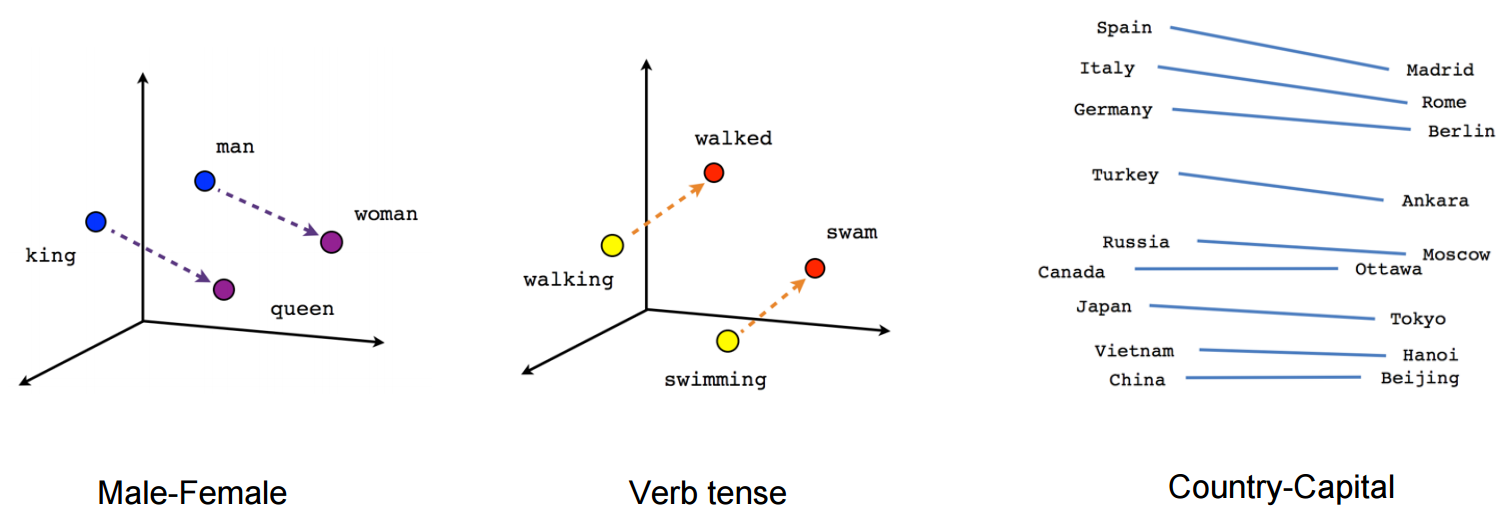

In [ ]:
# --- Build a ROW-ALIGNED words_list (row i -> correct string) ---
n_rows = vectors.shape[0]
row2key = [None] * n_rows
for key, row in vectors.key2row.items():
    row2key[row] = key

words_list = [nlp.vocab.strings[k] for k in row2key]

# --- Build normalized matrix: Vnorm[row] is unit vector for that row ---
V = vectors.data.astype("float32")
Vnorm = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)


def cosine(u, v):
    return float(np.dot(u, v) / ((np.linalg.norm(u) * np.linalg.norm(v)) + 1e-12))


def analogy(a, b, c, topn=5):
    a0, b0, c0 = a.lower().strip(), b.lower().strip(), c.lower().strip()

    if not (nlp.vocab[a0].has_vector and nlp.vocab[b0].has_vector and nlp.vocab[c0].has_vector):
        return []

    r = nlp.vocab[a0].vector - nlp.vocab[b0].vector + nlp.vocab[c0].vector
    r = r / (np.linalg.norm(r) + 1e-12)

    sims = Vnorm @ r
    best = sims.argsort()[-(topn + 50):][::-1]

    out = []
    banned = {a0, b0, c0}
    for i in best:
        w = words_list[int(i)]
        wl = w.lower()

        if wl in banned:
            continue
        if len(w) <= 1:
            continue
        if not w.isalpha():
            continue

        out.append((w, float(sims[i])))
        if len(out) >= topn:
            break

    return out


print(analogy("king", "man", "woman", topn=5))
print(analogy("walking", "walked", "running", topn=5))

[('QUEEN', 0.7880843877792358), ('PRINCE', 0.6401078104972839), ('KINGS', 0.620854377746582), ('PRINCESS', 0.6125636100769043), ('ROYAL', 0.5800970196723938)]
[('RUN', 0.5862648487091064), ('JOGGING', 0.5184155702590942), ('CYCLING', 0.5111332535743713), ('BIKING', 0.5066318511962891), ('Runing', 0.4835926294326782)]


#### Exercise — "doctor - man + woman"
1. Run the analogy.
2. Measure cosine to "nurse" vs "doctor".
3. Interpret the result: model behavior vs societal bias vs corpus effects.

### 5.5 Sentence embeddings (static): mean pooling vs IDF-weighted pooling

#### Why do we need pooling?

Word2Vec-style embeddings give us **vectors for words**, not for sentences.  
To obtain a sentence vector, we need a **composition function** that combines word vectors.

A common baseline is **mean pooling**:
- Take the average of the word vectors in the sentence

This is simple but ignores:
1. **Word importance** – "the", "a" contribute equally to rare content words
2. **Word order** – permutation invariant

#### Improvement: IDF-weighted pooling

Weight each word by its inverse document frequency:
$$\text{IDF}(w) = \log\left(\frac{N}{\text{df}(w)}\right)$$

This gives higher weight to rare, informative words.

We show both methods below.

#### Limitations

Static embeddings cannot capture:
- Word order
- Context-dependent meaning
- Long-range dependencies

Contextual models (BERT, etc.) address some of these issues.

In [ ]:
from collections import defaultdict

mini_corpus = [
    "Cats are beautiful animals.",
    "Some gorgeous creatures are felines.",
    "Dolphins are swimming mammals.",
    "Banks can approve loans quickly.",
    "The river bank was covered in mud."
]

def compute_idf(texts, nlp):
    df = defaultdict(int)
    N = len(texts)
    for t in texts:
        doc = nlp(t.lower())
        seen=set()
        for tok in doc:
            if tok.is_alpha:
                seen.add(tok.text)
        for w in seen:
            df[w]+=1
    idf = {w: math.log((N+1)/(df[w]+1)) + 1.0 for w in df}
    return idf

idf = compute_idf(mini_corpus, nlp)

def sentence_vector_mean(text, nlp):
    doc = nlp(text)
    vecs = [t.vector for t in doc if t.has_vector and t.is_alpha]
    if not vecs:
        return np.zeros(nlp.vocab.vectors_length, dtype=np.float32)
    v = np.mean(vecs, axis=0)
    return v / (np.linalg.norm(v)+1e-12)

def sentence_vector_idf(text, nlp, idf):
    doc = nlp(text.lower())
    vecs=[]
    weights=[]
    for t in doc:
        if t.has_vector and t.is_alpha:
            w = idf.get(t.text, 1.0)
            vecs.append(t.vector)
            weights.append(w)
    if not vecs:
        return np.zeros(nlp.vocab.vectors_length, dtype=np.float32)
    vecs=np.vstack(vecs)
    weights=np.array(weights).reshape(-1,1)
    v = (vecs*weights).sum(axis=0) / (weights.sum()+1e-12)
    return v / (np.linalg.norm(v)+1e-12)

s1 = "Cats are beautiful animals."
s2 = "Some gorgeous creatures are felines."
s3 = "Dolphins are swimming mammals."

v1m, v2m, v3m = sentence_vector_mean(s1,nlp), sentence_vector_mean(s2,nlp), sentence_vector_mean(s3,nlp)
v1i, v2i, v3i = sentence_vector_idf(s1,nlp,idf), sentence_vector_idf(s2,nlp,idf), sentence_vector_idf(s3,nlp,idf)

print("mean sim(s1,s2):", cosine(v1m,v2m), " | mean sim(s1,s3):", cosine(v1m,v3m))
print("idf  sim(s1,s2):", cosine(v1i,v2i), " | idf  sim(s1,s3):", cosine(v1i,v3i))


mean sim(s1,s2): 0.8916929960250854  | mean sim(s1,s3): 0.7351893186569214
idf  sim(s1,s2): 0.8780919219552886  | idf  sim(s1,s3): 0.7049792262421245


#### Exercise — evaluate pooling methods
Create 10 sentence pairs (5 similar, 5 dissimilar) and compare mean vs IDF-weighted similarities.

### 5.6 Sentiment analysis baseline (logistic regression + sentence vectors)

We build a simple baseline classifier using sentence vectors as features.

The major reason for coming up with word embedding models is that we want to use these embeddings which encode the word semantics to help us tackle problems related with natural language.

One such task is sentiment analysis. By analyzing the sentiment of texts, we want to understand whether a given sentence/document is positive or negative. For example, 'the weather is so nice today' has a positive sentiment whereas 'he is bored by the movie' has a negative sentiment.

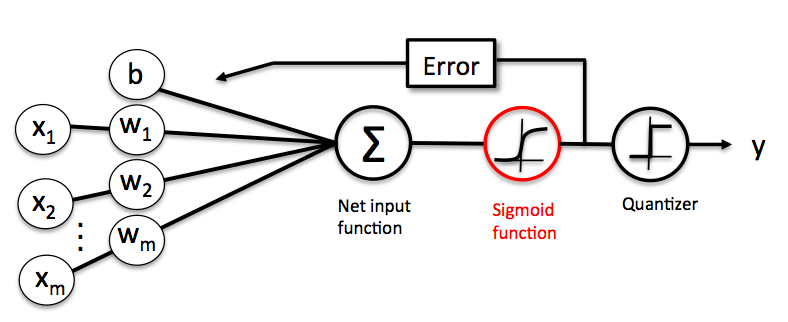

Our training data contains 2,748 from Yelp reviews, IMDB movie reviews, and Amazon reviews. In the dataset, 1 means positive and 0 means negative. The original data can be downloaded from [here](https://www.kaggle.com/rahulin05/sentiment-labelled-sentences-data-set/data), the combined file can be downloaded from [here](https://drive.google.com/file/d/1knrjvDNkiXtviXBoLm5OJY45_kcCmDxe/view?usp=sharing).



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data = [
    ("this movie was fantastic and inspiring", 1),
    ("absolutely loved the film and the acting", 1),
    ("what a terrible plot and boring scenes", 0),
    ("the food was amazing and service was great", 1),
    ("horrible experience, never coming back", 0),
    ("the product broke after one day", 0),
    ("super happy with the purchase", 1),
    ("waste of money and time", 0),
    ("really enjoyed it, would recommend", 1),
    ("disappointing and poorly made", 0),
]

X = np.vstack([sentence_vector_idf(t, nlp, idf) for t,y in data])
y = np.array([y for t,y in data])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
print(classification_report(yte, pred, digits=3))


              precision    recall  f1-score   support

           0      0.000     0.000     0.000         2
           1      0.333     1.000     0.500         1

    accuracy                          0.333         3
   macro avg      0.167     0.500     0.250         3
weighted avg      0.111     0.333     0.167         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Exercise 1 — Actual Prediction
1. Download the dataset and train with the smaller combined one instead of the few sentences given in the code
2. Optional - Train with the full datasets

#### Exercise 2 — stronger baselines
1. Compare mean pooling vs IDF pooling for sentiment.
2. Compare embeddings-based classifier vs bag-of-words (CountVectorizer + LogisticRegression).
3. Discuss: when do embeddings help, and when do they hurt?

### 5.7 The big limitation: polysemy & context (static embeddings fail)

Static embeddings provide **one vector per word type**, so a word like **bank** conflates senses (finance vs river bank).

With static embeddings, the vector for "bank" **cannot change** with context.

In [ ]:
sA = "The bank approved the mortgage quickly."
sB = "The river bank was covered in mud."

docA = nlp(sA)
docB = nlp(sB)

bankA = [t for t in docA if t.text.lower() == "bank"][0]
bankB = [t for t in docB if t.text.lower() == "bank"][0]

print("token vectors identical in static embedding space?:", np.allclose(bankA.vector, bankB.vector))
print("cos(bankA, bankB):", cosine(bankA.vector, bankB.vector))


token vectors identical in static embedding space?: True
cos(bankA, bankB): 1.0


#### Closing note: why contextual embeddings exist

To model polysemy, we need **contextual embeddings** (ELMo, BERT, etc.), where:
- "bank" in sentence A and B yields different token vectors

**Optional extension for advanced section:** Come back after completing Activity 4 and use a transformer-based spaCy model (`en_core_web_trf`) and compare contextual token vectors for "bank" across contexts.

# Curated References (cleaned)

- Mikolov et al. (2013) *Efficient Estimation of Word Representations in Vector Space*
- Mikolov et al. (2013) *Distributed Representations of Words and Phrases and their Compositionality* (negative sampling)
- Levy & Goldberg (2014) *Neural word embedding as implicit matrix factorization*
- Jalammar — *The Illustrated Word2Vec*
- TensorFlow word2vec tutorial notebook
- Gensim documentation: Word2Vec and KeyedVectors APIs

https://github.com/jalammar/jalammar.github.io/blob/master/notebooks/nlp/01_Exploring_Word_Embeddings.ipynb